# WalSmart - Targeted Marketing

### Project Notebook 1 - Data Exploration
Margarida Sardinha | 20221959

Master's in Information Management - Data Mining I

## 1. Imports

In [2]:
# Importing needed libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
# Loading the dataset
data = pd.read_csv('NOVAIMS_projectData_B2C_202526.csv')

## 2. Data types and missing values

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123683 entries, 0 to 123682
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID_Client               123354 non-null  object 
 1   Frequency_items         123683 non-null  int64  
 2   Potencial_Score         123683 non-null  float64
 3   ZIP_Code                123089 non-null  object 
 4   Longevity_months        123683 non-null  int64  
 5   Latitude                123683 non-null  float64
 6   Longitude               123683 non-null  float64
 7   Credit_factor           123683 non-null  float64
 8   Relevance_criteria      123683 non-null  object 
 9   Store_state             123683 non-null  object 
 10  Recency_in_weeks        123683 non-null  int64  
 11  Returns                 123683 non-null  int64  
 12  ID_Store_last           123683 non-null  int64  
 13  Gender                  42566 non-null   object 
 14  Flaged              

In [5]:
# Missing values
data.isna().sum()

Missing Values


ID_Client                   329
Frequency_items               0
Potencial_Score               0
ZIP_Code                    594
Longevity_months              0
Latitude                      0
Longitude                     0
Credit_factor                 0
Relevance_criteria            0
Store_state                   0
Recency_in_weeks              0
Returns                       0
ID_Store_last                 0
Gender                    81117
Flaged                        0
Promotional_percentage        0
Education                 51850
Checked_ok                    0
Beer                          0
Bottled_Water                 0
Bread                         0
Meat                          0
Dairy                         0
Fresh_Foods                   0
Frozen_Foods                626
Fruit_Beverages               0
Pastry                        0
Sodas                         0
Toiletries                    0
Veggies                       0
Wines                         0
dtype: i

## 3. Variable Distributions

In [6]:
# Correcting data types
data["Dairy"] = pd.to_numeric(
    data["Dairy"].astype(str).str.replace(",000", "", regex=False).str.strip(),
    errors="coerce"
)

data["ID_Store_last"] = data["ID_Store_last"].astype("category")

### 3.1. Numeric variables

In [7]:
data.describe(include='number')

,Frequency_items,Potencial_Score,Longevity_months,Latitude,Longitude,Credit_factor,Recency_in_weeks,Returns,Flaged,Promotional_percentage,...,Meat,Dairy,Fresh_Foods,Frozen_Foods,Fruit_Beverages,Pastry,Sodas,Toiletries,Veggies,Wines
count,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,...,123683.000000,123683.000000,123683.000000,123057.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000
mean,38.261224,30.392316,13.665354,25.249363,6.158188,0.899913,11.244706,4.310972,0.010373,13.940888,...,4.413606,48.347057,62.666826,74.222564,49.562155,51.366865,36.884891,19.181545,23.499664,16.204216
std,13.594001,99.673585,9.881178,29.997630,7.697199,0.799920,3.799946,27.629597,0.101639,54.416311,...,65.663578,81.981802,142.515009,135.669123,78.762338,52.097284,97.267381,18.939219,167.137181,59.304674
min,1.000000,-1.000000,-12.000000,-5.000000,-5.000000,0.000000,-4.000000,-87.000000,0.000000,-2140.000000,...,-53.000000,0.000000,-33.000000,-35.000000,-17.000000,0.000000,-954.000000,-24.000000,-45.000000,-85.000000
25%,29.000000,0.800000,6.000000,-0.166667,-0.166667,0.700000,9.000000,0.000000,0.000000,0.000000,...,0.000000,28.000000,28.000000,30.000000,17.000000,28.000000,12.000000,9.000000,7.000000,4.000000
50%,37.000000,24.058840,13.000000,1.000000,1.000000,0.700000,11.000000,0.000000,0.000000,8.000000,...,0.000000,31.000000,45.000000,60.000000,28.000000,32.000000,32.000000,19.000000,18.000000,13.000000
75%,47.000000,39.701604,21.000000,60.126211,13.971501,1.000000,14.000000,0.000000,0.000000,16.000000,...,0.000000,78.000000,100.000000,109.000000,90.000000,47.000000,52.000000,27.000000,30.000000,23.000000
max,131.000000,11481.040830,45.000000,72.170287,30.973885,28.400000,18.000000,591.000000,2.000000,4920.000000,...,6771.000000,4885.000000,23100.000000,12806.000000,9828.000000,3592.000000,5981.000000,1612.000000,28375.000000,9621.000000


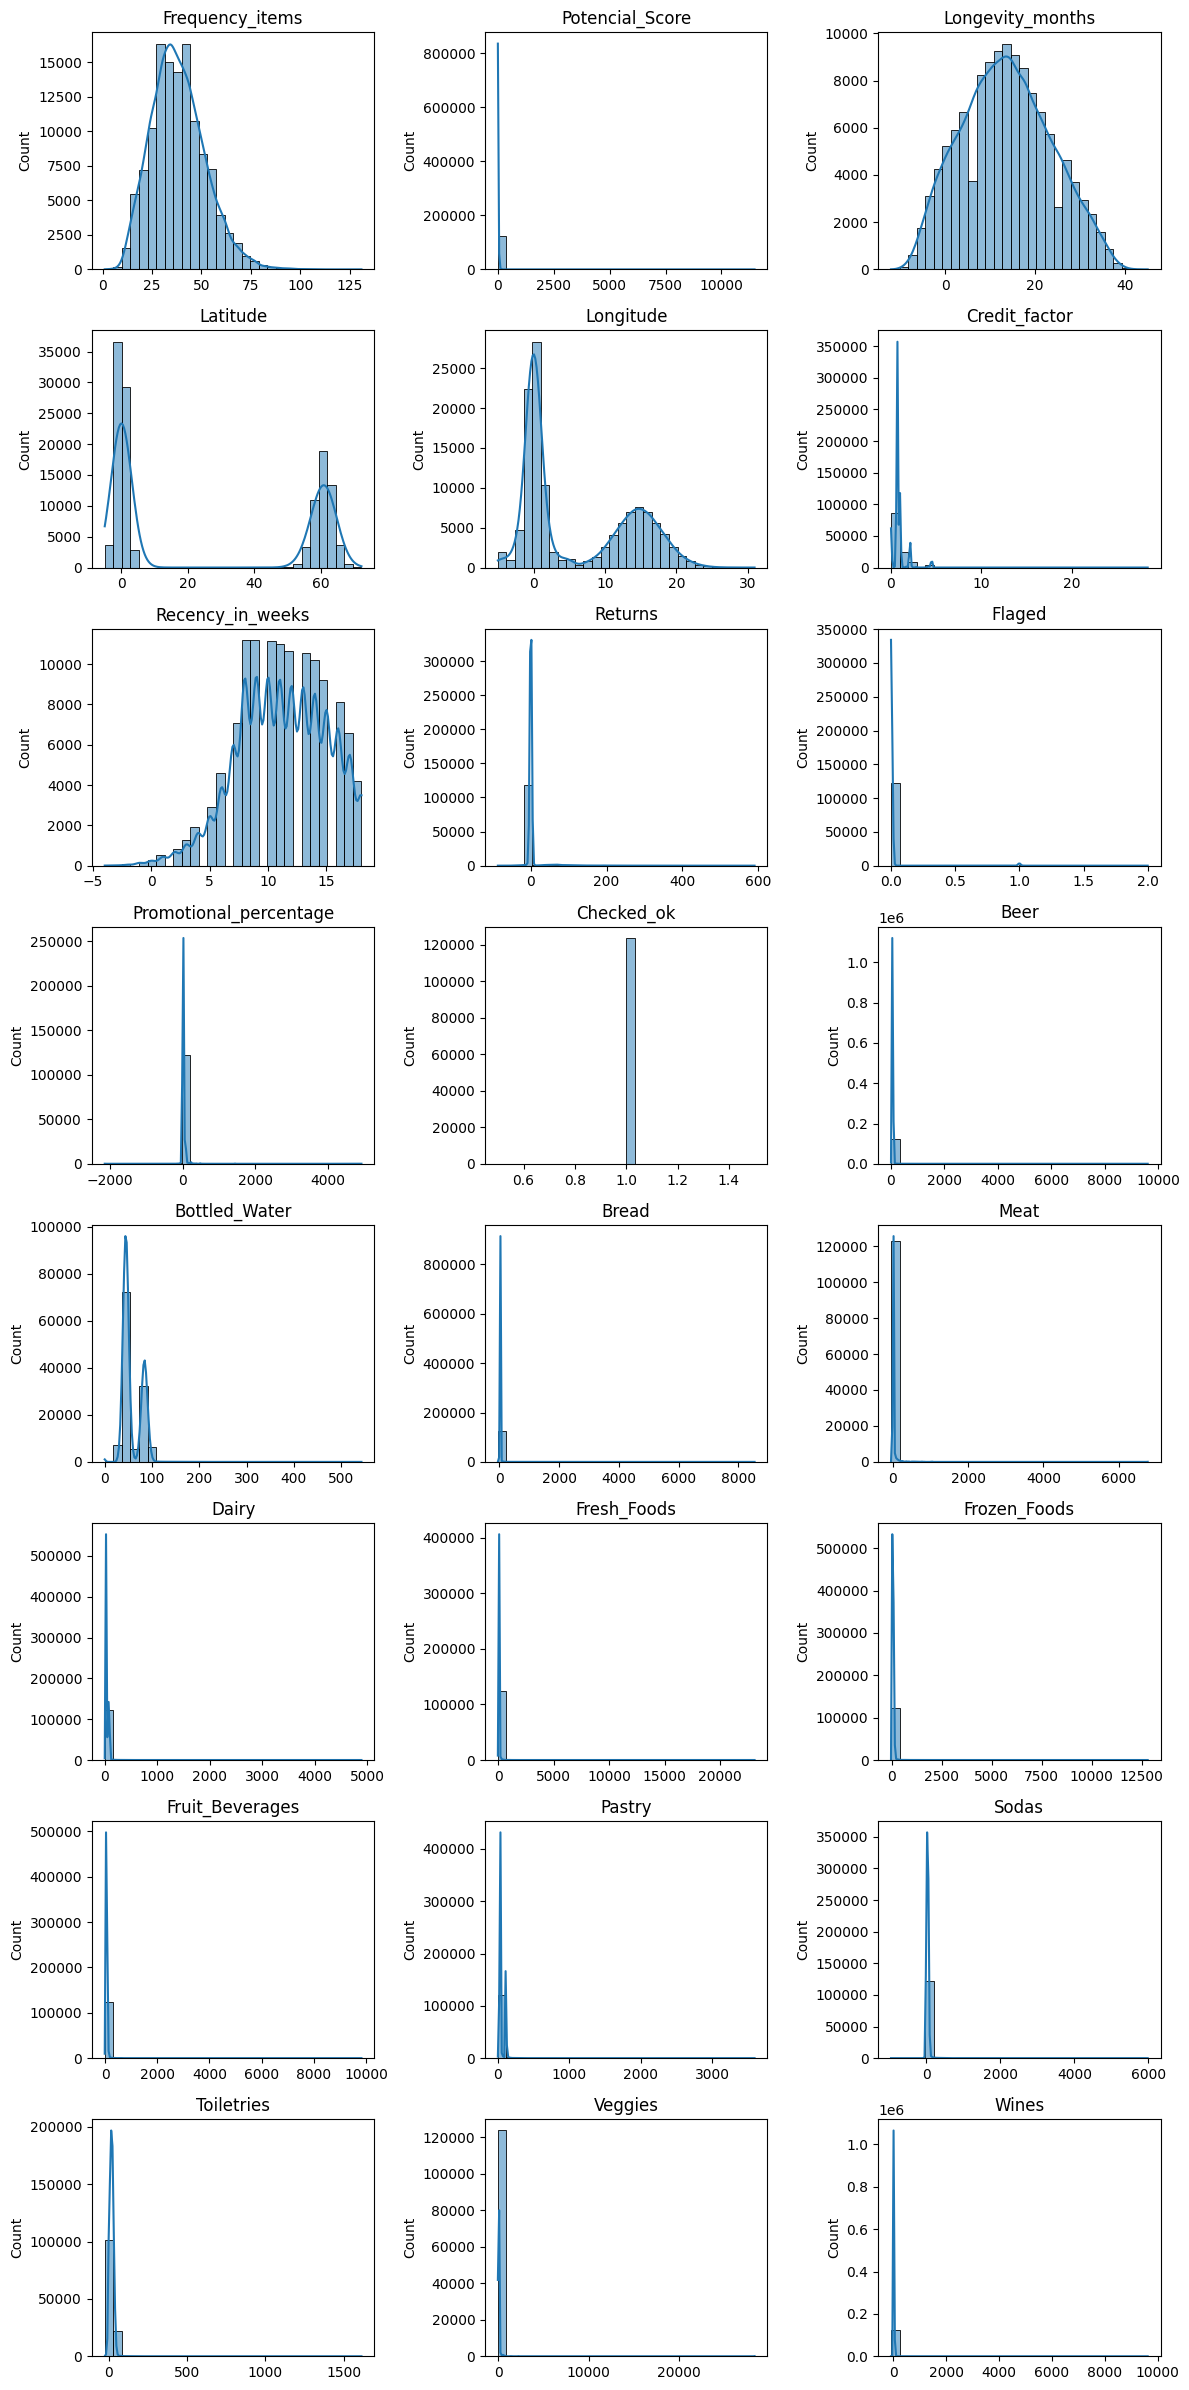

In [8]:
# Select numeric columns
numeric_cols = data.select_dtypes(include=["number"]).columns.tolist()

# Plot distributions
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data[col].dropna(), kde=True, ax=ax, bins=30)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### 3.2. Categorical variables

In [9]:
data.describe(include='object')

,ID_Client,ZIP_Code,Relevance_criteria,Store_state,Gender,Education
count,123354,123089,123683,123683,42566,71833
unique,122803,9,3,1,7,6
top,,8,Priority,NSW,male,High School
freq,288,67808,115847,123683,12408,26510


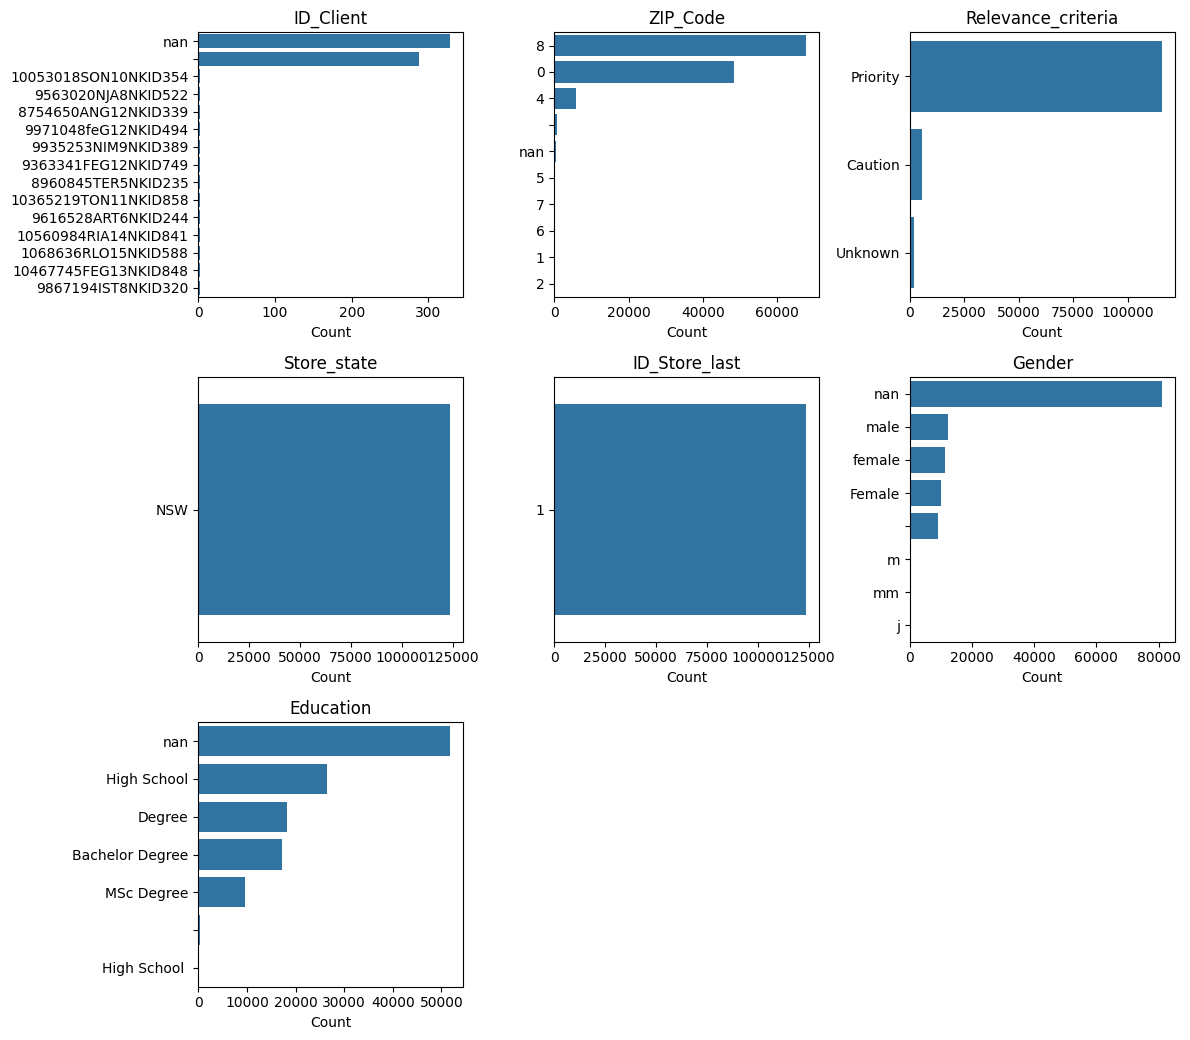

In [10]:
# Select categorical columns
cat_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()

# Plot value counts
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    # Plot counts (sorted by frequency)
    vc = data[col].value_counts(dropna=False)
    sns.barplot(x=vc.head(15).values, y=vc.head(15).index.astype(str), ax=ax, orient="h")
    ax.set_title(col)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### 3.3. Product variables deep dive

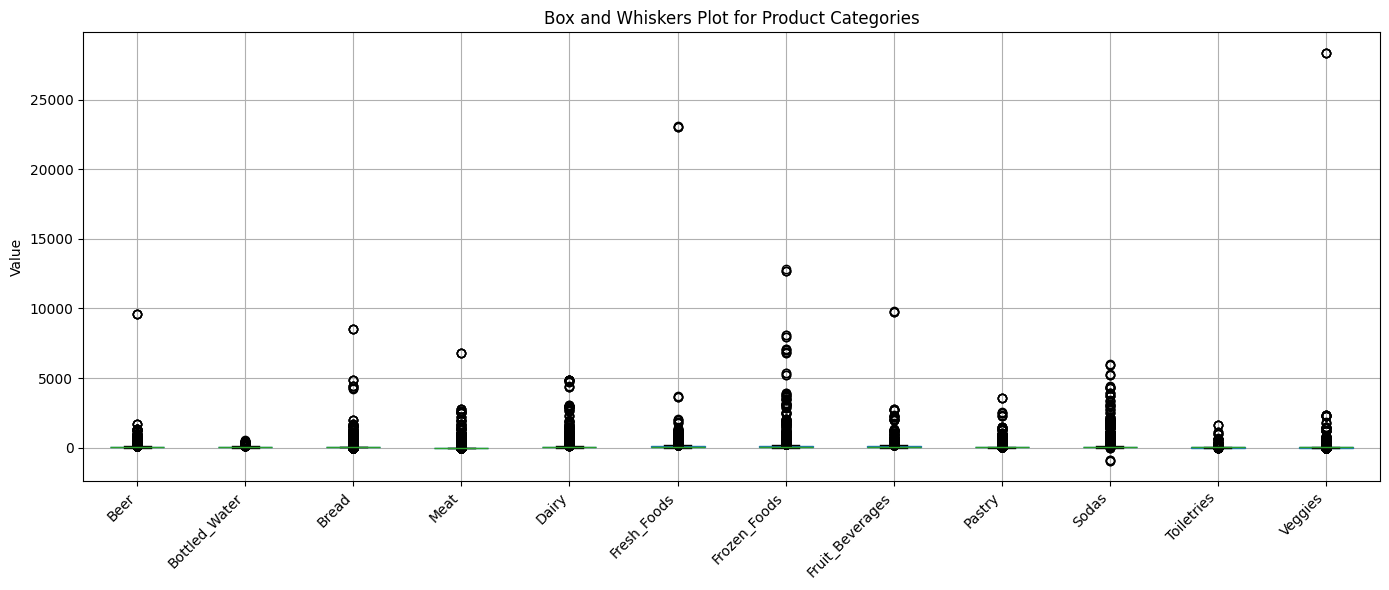

In [19]:
# Box and whiskers plot for product categories
product_cols = [
    'Beer', 'Bottled_Water', 'Bread', 'Meat', 'Dairy', 'Fresh_Foods',
    'Frozen_Foods', 'Fruit_Beverages', 'Pastry', 'Sodas', 'Toiletries', 'Veggies'
]

# Create boxplot
plt.figure(figsize=(14, 6))
data[product_cols].boxplot(vert=True, patch_artist=True)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Value')
plt.title('Box and Whiskers Plot for Product Categories')
plt.tight_layout()
plt.show()

## 4. Deep Dives

In [12]:
lon_non_missing = data["Longevity_months"].dropna()

# Impossible values
pct_below_0 = (lon_non_missing < 0).mean() * 100
# Older than the store itself
pct_above_96 = (lon_non_missing > 96).mean() * 100

print(f"Percentage below 0 (non-missing): {pct_below_0:.2f}%")
print(f"Percentage above 96 (non-missing): {pct_above_96:.2f}%")

Percentage below 0 (non-missing): 7.95%
Percentage above 96 (non-missing): 0.00%


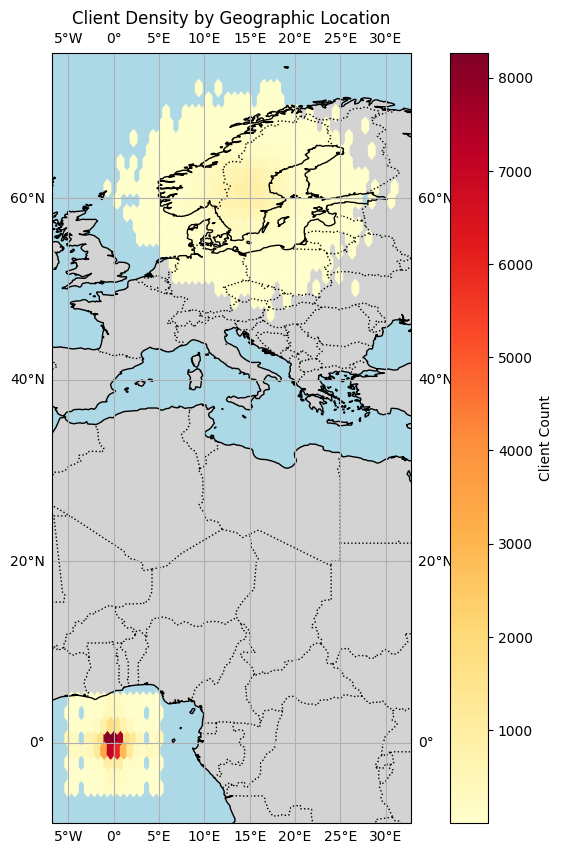

In [13]:
# Client density by geographic location
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

hb = ax.hexbin(data['Longitude'], data['Latitude'], gridsize=50, 
               cmap='YlOrRd', mincnt=1, transform=ccrs.PlateCarree())
plt.colorbar(hb, ax=ax, label='Client Count')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Client Density by Geographic Location')
ax.gridlines(draw_labels=True)
plt.show()

In [14]:
valid = (~data["Latitude"].isna()) & (~data["Longitude"].isna())
in_band = data["Latitude"].between(-5, 5) & data["Longitude"].between(-5, 5)
pct_in_band = (in_band[valid].mean() * 100) if valid.any() else 0.0

print(f"Percentage of valid lat-lon pairs between -5 and 5: {pct_in_band:.2f}%")

Percentage of valid lat-lon pairs between -5 and 5: 58.43%


In [15]:
pct_zero = (data["Returns"] == 0).mean() * 100
pct_below_zero = (data["Returns"] < 0).mean() * 100

print(f"Percentage of 0s (non-missing): {pct_zero:.2f}%")
print(f"Percentage below 0 (non-missing): {pct_below_zero:.2f}%")

Percentage of 0s (non-missing): 93.87%
Percentage below 0 (non-missing): 1.67%


In [16]:
gender_lower = data["Gender"].astype(str).str.lower().str.strip()
valid_genders = gender_lower.isin(["female", "f", "m", "mm", "male"])
pct_valid = valid_genders.mean() * 100

print(f"Percentage of valid gender values: {pct_valid:.2f}%")

Percentage of valid gender values: 27.16%


In [17]:
# Distribution of Flagged variable
flagged_counts = data["Flaged"].value_counts(dropna=False)
flagged_pct = data["Flaged"].value_counts(dropna=False, normalize=True) * 100

print(flagged_pct)

Flaged
0    98.965905
1     1.030861
2     0.003234
Name: proportion, dtype: float64


In [18]:
# Percentage of missing Education values
print(data['Education'].isna().mean()*100)

41.921686893105765


In [27]:
# Checking for valid Promotional_percentages
valid = data['Promotional_percentage'].between(0, 100).mean() * 100
print(f'Valid:', valid)

pct_below_0 = (data['Promotional_percentage'] < 0).mean() * 100
pct_above_100 = (data['Promotional_percentage'] > 100).mean() * 100

print(f'Below 0:', pct_below_0)
print(f'Above 100:', pct_above_100)

Valid: 97.66095583063154
Below 0: 1.1747774552687111
Above 100: 1.164266714099755


## 5. Findings

|Variable                | Group  | Issue                           | Fix                             |
|------------------------|--------|---------------------------------|---------------------------------|
|ID_Client               | ID     | Missing and null values at random | Remove all missing and null rows|
|Potencial_Score         | -      | Computed based on the same data | Remove from dataset             |
|Frequency_items         | Value  | No issue                        |                                 |
|ZIP_Code                | Value  | Very imbalanced, missing data   | Create ZIP_Missing, ZIP_Others, and one-hot encode the 3 most common values (assuming these are valid zone codes) |
|Longevity_months        | Value  | Negative values at random       | Replace negative values with 0 (First purchase on 31/12/2023) |
|Latitude                | -      | Error cluster around [-5, 5]    | Remove from dataset             |
|Longitude               | -      | Error cluster around [-5, 5]    | Remove from dataset             |
|Credit_factor           | -      | Computed based on the same data | Remove from dataset             |
|Relevance_criteria      | Value  | Very imbalanced                 | Replace with a Relevance_Priority column |
|Store_state             | -      | Adds no information             | Remove from dataset             |
|Recency_in_weeks        | Value  | Negative values at random       | Replace negative values with 0 (Last purchase on 31/12/2023)  |
|Returns                 | Value  | 94% null values                 | Replace with a Has_Returns column |
|ID_Store_last           | -      | Adds no information             | Remove from dataset             |
|Gender                  | -      | Low density, only 27% valid inputs | Remove from dataset          |
|Flaged                  | Value  | False boolean                   | Replace 2 with 1 and make boolean |
|Promotional_percentage  | Basket | False percentage                | Make absolute and clip to scale to [0, 100] |
|Education               | Value  | Non-normalized labels, missing values (41%) | Replace with Education_Years, assuming empty rows are at least High School |
|Checked_ok              | -      | Adds no information             | Remove from dataset |
|Beer                    | Basket | Very right-skewed               | Apply log transformation        |
|Bottled_Water           | Basket | Very right-skewed               | Apply log transformation        |
|Bread                   | Basket | Very right-skewed               | Apply log transformation        |
|Meat                    | Basket | Very right-skewed               | Apply log transformation        |
|Dairy                   | Basket | Wrong data type, very right-skewed | Cast as numeric, apply log transformation        |
|Fresh_Foods             | Basket | Very right-skewed, outlier      | Apply log transformation, windsorize |
|Frozen_Foods            | Basket | Missing values, very right-skewed| Fill missing values through imputation, apply log transformation        |
|Fruit_Beverages         | Basket | Very right-skewed               | Apply log transformation        |
|Pastry                  | Basket | Very right-skewed               | Apply log transformation        |
|Sodas                   | Basket | Very right-skewed               | Apply log transformation        |
|Toiletries              | Basket | Very right-skewed               | Apply log transformation        |
|Veggies                 | Basket | Very right-skewed, outlier      | Apply log transformation, windsorize |
|Wines                   | Basket | Very right-skewed               | Apply log transformation        |

Notes:
- I will assume the values in ZIP_Code are valid zone codes for the country WalSmart is in;
- If I removed only the error values from Latitude/Longitude, we would be left with only 42% of data, so I will remove the variables instead;
- Assumming the variables Credit_factor and Potential_Score were computed using the same data we see here, they cannot be used since they may bias the final result through adding the structure of the model that was used to create them (instead of the final result here being just due to the raw data, it will also include the other models' bias);
- In Education, I will assume "degree" stands for Bachelor's Degree, and that the minimum mandatory education is High School;
- Negative values in the basket columns are OK since they represent profit, not sales. The negatives could simply be that the category is being sold at a loss;
- I will apply windsorization to deal with outliers, replacing them with the 99th percentile.